<a href="https://colab.research.google.com/github/yizhifantuan/clay-Remote-Sensing-Model/blob/main/%E7%A4%BA%E4%BE%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**克隆并安装Clay**

In [1]:
!git clone https://github.com/Clay-foundation/model.git
%cd /content/model

!pip install -q -e .

Cloning into 'model'...
remote: Enumerating objects: 2959, done.
remote: Counting objects: 100% (945/945), done.
remote: Compressing objects: 100% (303/303), done.
remote: Total 2959 (delta 777), reused 642 (delta 642), pack-reused 2014 (from 2)
Receiving objects: 100% (2959/2959), 210.87 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (1823/1823), done.
/content/model
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

**下载 Clay v1.5 权重**

In [3]:
%cd /content/model

!wget -q --show-progress \
  https://huggingface.co/made-with-clay/Clay/resolve/main/v1.5/clay-v1.5.ckpt \
  -O clay-v1.5.ckpt

!ls -lh clay-v1.5.ckpt

/content/model
clay-v1.5.ckpt      100%[===================>]   4.80G  75.9MB/s    in 1m 42s  
-rw-r--r-- 1 root root 4.9G Aug  5 07:40 clay-v1.5.ckpt


**使用GPU**

In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [6]:
!pip install pystac-client stackstac geopandas python-box shapely rasterio torch torchvision matplotlib pyyaml scikit-learn numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.5 MB/s eta 0:00:00


**导入包**

In [7]:
import math

import geopandas as gpd
import numpy as np
import pandas as pd
import pystac_client
import stackstac
import torch
import yaml
from box import Box
from matplotlib import pyplot as plt
from rasterio.enums import Resampling
from shapely import Point
from sklearn import decomposition, svm
from torchvision.transforms import v2

from claymodel.module import ClayMAEModule

**定义研究区与时序范围**

In [8]:
# Point over Monchique Portugal
lat, lon = 37.30939, -8.57207
# Dates of a large forest fire
start = "2018-07-01"
end = "2018-09-01"

**从 AWS STAC 接口检索 Sentinel-2 影像**

In [9]:
# 定义STAC服务接口地址
STAC_API = "https://earth-search.aws.element84.com/v1"
# 指定要检索的数据集名称
COLLECTION = "sentinel-2-l2a"
# 打开STAC目录客户端，连接API服务
catalog = pystac_client.Client.open(STAC_API)
# 发起影像检索请求，传入所有筛选条件
search = catalog.search(
    collections=[COLLECTION],
    datetime=f"{start}/{end}",
    bbox=(lon - 1e-5, lat - 1e-5, lon + 1e-5, lat + 1e-5),
    max_items=100,
    # 只保留整景云量小于 80% 的影像，过滤多云数据
    query={"eo:cloud_cover": {"lt": 80}},
)
# 将检索结果全部读取为影像集合对象
all_items = search.item_collection()

# 初始化两个空列表：存储去重后的影像、记录已保存过的日期
items = []
dates = []
for item in all_items:
  # 判断当前影像的拍摄日期 是否不在已记录日期列表中
    if item.datetime.date() not in dates:
        items.append(item)
        dates.append(item.datetime.date())
print(f"Found {len(items)} items")
# 输出 Found 12 items

Found 12 items


**构建模型输入影像切片框（256×256 像素）**

In [11]:
# 从第一条匹配到的哨兵影像中提取坐标系信息
epsg = int(items[0].properties["proj:epsg"])

# WGS84 单点转影像 UTM 投影坐标
# GeoPandas 地理数据框，专门存储带空间几何坐标的数据
poidf = gpd.GeoDataFrame(
    pd.DataFrame(), # 传入空 Pandas 基础表格，仅作容器载体
    crs="EPSG:4326",
    geometry=[Point(lon, lat)], # 几何列赋值，创建一个单点几何对象，lon经度、lat纬度，包裹列表代表仅 1 个点位
).to_crs(epsg) # 坐标系转换
# 提取转换后的 XY 坐标
coords = poidf.iloc[0].geometry.coords[0]

# 裁剪瓦片像素尺寸：宽高都是256像素
size = 256
# GSD地面采样距离：哨兵2可见光波段1个像素=地面10米
gsd = 10
bounds = (
    coords[0] - (size * gsd) // 2,
    coords[1] - (size * gsd) // 2,
    coords[0] + (size * gsd) // 2,
    coords[1] + (size * gsd) // 2,
)

** Retrieve the imagery data 用 stackstac 批量下载、拼接时序栅格**

In [12]:
# Retrieve the pixel values for target bbox & projection
stack = stackstac.stack(
    items, # 数据源
    bounds=bounds, # 裁剪范围
    snap_bounds=False, # 边界对齐像素格开关
    epsg=epsg, # 输出坐标系
    resolution=gsd, # 输出像素地面分辨率
    dtype="float64",
    rescale=False, # 是否自动缩放DN值转反射率
    fill_value=0, # 空白/无数据填充值
    assets=["blue", "green", "red", "nir"], # 只读取这四个波段
    resampling=Resampling.nearest, # 重采样插值方式
)
print(stack)
# 实际下载、生成 (时间，4波段，256,256) 四维遥感数组
stack = stack.compute()

<xarray.DataArray 'stackstac-67eb04bcc5abc426128dae97fbbb4b9f' (time: 12,
                                                                band: 4,
                                                                y: 256, x: 256)> Size: 25MB
dask.array<fetch_raster_window, shape=(12, 4, 256, 256), dtype=float64, chunksize=(1, 1, 256, 256), chunktype=numpy.ndarray>
Coordinates: (12/53)
  * time                                     (time) datetime64[ns] 96B 2018-0...
  * band                                     (band) <U5 80B 'blue' ... 'nir'
  * y                                        (y) float64 2kB 4.131e+06 ... 4....
  * x                                        (x) float64 2kB 5.366e+05 ... 5....
    id                                       (time) <U24 1kB 'S2B_29SNB_20180...
    s2:medium_proba_clouds_percentage        (time) float64 96B 5.48 ... 1.105
    ...                                       ...
    proj:shape                               object 8B {10980}
    proj:transform    

** 可视化全部时序 RGB 真彩色影像**

In [2]:
# 可视化图像
stack.sel(band=["red", "green", "blue"]).plot.imshow(
    row="time", rgb="band", vmin=0, vmax=2000, col_wrap=6
)

NameError: name 'stack' is not defined

**加载 Clay-v1.5 MAE 预训练权重**

In [15]:
# 判断是否有显卡
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# 定义权重文件路径
ckpt = "clay-v1.5.ckpt"
# 设置全局默认运算设备
torch.set_default_device(device)
# 加载预训练 MAE 模型核心代码
model = ClayMAEModule.load_from_checkpoint( # PL框架专用函数，直接从ckpt权重文件完整恢复模型+参数
    ckpt,
    model_size="large",
    # 存储遥感卫星波段信息（Sentinel、Landsat 等波段名称、波长、归一化参数），模型读取用来处理影像
    metadata_path="/content/model/configs/metadata.yaml",
    # CLAY 多尺度分块编码维度列表，对应不同遥感分辨率的特征通道维度
    dolls=[16, 32, 64, 128, 256, 768, 1024],
    # 上面多尺度特征对应的损失权重，全部设为 1 代表所有尺度同等重要
    doll_weights=[1, 1, 1, 1, 1, 1, 1],
    #  掩码比例
    mask_ratio=0.0,
    # 是否打乱
    shuffle=False,
)
#评估模式
model.eval()
model = model.to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

**读取波段归一化参数与波长**

In [16]:
# 从元配置文件提取每个波段的归一化均值、标准差、光谱中心波长
platform = "sentinel-2-l2a"
# 读取yaml文件内容，转换成Python字典，把普通字典包装成Box对象
metadata = Box(yaml.safe_load(open("/content/model/configs/metadata.yaml")))
mean = [] # 当前影像所有波段对应的归一化均值
std = []  # 当前影像所有波段对应的归一化标准差
waves = [] # 当前影像所有波段对应的光谱中心波长

# Match stack波段顺序，提取对应归一化均值、方差、中心波长
for band in stack.band:
  # band.values拿到波段名字，转字符串用来匹配yaml配置文件里的键
  # metadata[platform]：选中哨兵-2的全部波段配置,读取所有波段的均值字典
    mean.append(metadata[platform].bands.mean[str(band.values)])
    std.append(metadata[platform].bands.std[str(band.values)])
    waves.append(metadata[platform].bands.wavelength[str(band.values)])

# 构建影像归一化变换,v2.Compose([...])：打包多个图像预处理操作，这里只有归一化一步
transform = v2.Compose(
    [
        v2.Normalize(mean=mean, std=std),
    ]
)

**时间、经纬度周期归一化 + 像素张量标准化**

In [17]:
# 用模型自带的归一化函数，预处理时间特征的嵌入向量
def normalize_timestamp(date):
    # 周编码：一年52周，转成0~2π完整圆周弧度，isocalendar().week 获取当前日期是一年第几周
    week = date.isocalendar().week * 2 * np.pi / 52
    # 小时编码：一天24小时，同样映射到0~2π圆周弧度
    hour = date.hour * 2 * np.pi / 24

    return (math.sin(week), math.cos(week)), (math.sin(hour), math.cos(hour))

# 数据集里所有样本的原始时间数组，转为s级标准时间格式，转换为Python datetime对象列表
datetimes = stack.time.values.astype("datetime64[s]").tolist()
# 遍历每一条时间，全部做周期编码
times = [normalize_timestamp(dat) for dat in datetimes]
week_norm = [dat[0] for dat in times]
hour_norm = [dat[1] for dat in times]


# 经纬度归一化编码
def normalize_latlon(lat, lon):
  # 角度转弧度：三角函数只能计算弧度
    lat = lat * np.pi / 180
    lon = lon * np.pi / 180

    return (math.sin(lat), math.cos(lat)), (math.sin(lon), math.cos(lon))

# 先算1组经纬度编码，再复制和时间样本数量等长，一一对应每条时间样本
latlons = [normalize_latlon(lat, lon)] * len(times)
lat_norm = [dat[0] for dat in latlons]
lon_norm = [dat[1] for dat in latlons]

# 影像像素预处理（转 torch 张量 + 图像标准化）
pixels = torch.from_numpy(stack.data.astype(np.float32))
# transform：预定义图像变换流水线
pixels = transform(pixels)

**组装模型输入字典 datacube**

In [18]:
# Prepare additional information
datacube = {
    "platform": platform,
    "time": torch.tensor(
        np.hstack((week_norm, hour_norm)),
        dtype=torch.float32,
        device=device,
    ),
    "latlon": torch.tensor(
        np.hstack((lat_norm, lon_norm)), dtype=torch.float32, device=device
    ),
    "pixels": pixels.to(device),
    "gsd": torch.tensor(stack.gsd.values, device=device),
    "waves": torch.tensor(waves, device=device),
}

**前向推理，提取全局影像嵌入向量**

In [19]:
with torch.no_grad():
  # unmsk_patch未被掩码遮挡的图块特征张量、unmsk_idx未遮挡图块对应的索引编号、msk_idx被掩码遮挡的图块索引、msk_matrix掩码矩阵，0=有效像素，1=遮挡像素
    unmsk_patch, unmsk_idx, msk_idx, msk_matrix = model.model.encoder(datacube)

# The first embedding is the class token, which is the
# overall single embedding. We extract that for PCA below.
embeddings = unmsk_patch[:, 0, :].cpu().numpy()

**PCA 降维可视化时序嵌入特征**

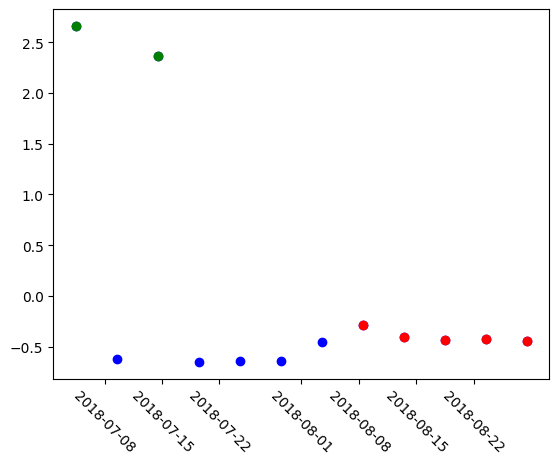

In [20]:
# PCA：主成分分析，把高维图像特征压缩成1 维数字，用来可视化图像差异
# 执行PCA降维
# 初始化PCA工具，n_components=1只保留一个主成分
pca = decomposition.PCA(n_components=1)
# 读取所有图像特征，自动学习数据分布规律，用学到的规则，把每张图的高维embedding压缩成1个数字
pca_result = pca.fit_transform(embeddings)

#把横轴时间标签逆时针旋转 45 度，防止文字挤在一起，看得更清晰
plt.xticks(rotation=-45)

# 先把所有影像全部画成蓝色散点
plt.scatter(stack.time, pca_result, color="blue")

# Re-plot cloudy images in green
plt.scatter(stack.time[0], pca_result[0], color="green")
plt.scatter(stack.time[2], pca_result[2], color="green")

# Color all images after fire in red
plt.scatter(stack.time[-5:], pca_result[-5:], color="red")

**SVM 微调火灾多分类任务**

In [ ]:
# 给下载好的图片打标签，规定三类编码
# 0 = Cloud
# 1 = Forest
# 2 = Fire
labels = np.array([0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2])

# 手动划分训练集、测试集索引
fit = [0, 1, 3, 4, 7, 8, 9]
test = [2, 5, 6, 10, 11]

# 创建 SVM 分类器 + 训练模型
clf = svm.SVC()
# 给所有特征数字统一加 100，取出训练集7张图片的特征向量，SVM学习特征区别
clf.fit(embeddings[fit] + 100, labels[fit])

# 测试集预测
prediction = clf.predict(embeddings[test] + 100)

# Perfect match for SVM
match = np.sum(labels[test] == prediction)
print(f"Matched {match} out of {len(test)} correctly")